# Assignment 2: The "Smart Labeling Pipeline" Challenge

**Total Marks: 20**

Build a cost-effective, high-quality labeling pipeline using human annotation, programmatic rules, and LLMs.

This notebook implements an end-to-end smart labeling pipeline to:
1. Establish gold standard through human annotation and measure inter-annotator agreement (6 marks)
2. Label data programmatically using weak supervision (Snorkel) (6 marks)
3. Optimize labeling budget using active learning (5 marks)
4. Leverage LLMs for bulk labeling and detect hallucinations (e.g. noisy labels) (3 marks)

## Setup and Imports

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from snorkel.labeling import labeling_function, PandasLFApplier, LFAnalysis
from snorkel.labeling.model import LabelModel
from statsmodels.stats.inter_rater import fleiss_kappa
import google.generativeai as genai
import time
from pathlib import Path
import re
print("All libraries imported successfully!")

All libraries imported successfully!


/mnt/c/GNSK/SEM-4/Software Tools and Techniques/assignment-2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_107792/1107263229.py:13: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


## Task 1: The Human as Annotator (6 Marks)

**Objective:** Establish a "Gold Standard" dataset and measure human consensus.

### Part 1.1: Parse Annotator CSV Files

After annotating the first 100 reviews, export annotations from three annotators (A, B, C) as CSV files.
Parse these CSV files into clean DataFrames for analysis.

In [ ]:
def parse_annotator_csv(csv_path):
    """
    Parses annotator CSV file into a clean DataFrame.
    
    Args:
        csv_path (str): Path to annotator CSV file
        
    Returns:
        pd.DataFrame: DataFrame with columns ['review', 'label']
                     where label is one of: 'Positive', 'Negative', 'Neutral'
    
    Note:
        - Handles Label Studio CSV exports (with 'annotations' column containing JSON)
        - Also handles simple CSV formats with direct 'review' and 'label' columns
        - Standardizes label values to: 'Positive', 'Negative', 'Neutral'
    """
    # Load CSV file using pd.read_csv()
    df = pd.read_csv(csv_path)
    
    # Method 1: Handle Label Studio exports (JSON in 'annotations' column)
    if 'annotations' in df.columns or 'annotation' in df.columns:
        reviews = []
        labels = []
        
        # Find the data column (contains review text)
        data_col = None
        for col in ['data', 'text', 'review']:
            if col in df.columns:
                data_col = col
                break
        
        # Find the annotations column
        annot_col = 'annotations' if 'annotations' in df.columns else 'annotation'
        
        for idx, row in df.iterrows():
            try:
                # Extract review text
                if data_col:
                    if isinstance(row[data_col], str) and row[data_col].startswith('{'):
                        # Data is JSON string, need to parse it
                        data_json = json.loads(row[data_col])
                        review_text = data_json.get('review', data_json.get('text', ''))
                    else:
                        review_text = row[data_col]
                else:
                    # Fallback: look for any column with text-like content
                    review_text = str(row.iloc[0])
                
                # Extract label from annotations
                annotations = row[annot_col]
                if isinstance(annotations, str):
                    # Parse JSON annotations
                    annot_json = json.loads(annotations)
                    if isinstance(annot_json, list) and len(annot_json) > 0:
                        # Get first annotation
                        result = annot_json[0].get('result', [])
                        if len(result) > 0:
                            # Extract label from 'value' -> 'choices'
                            label = result[0].get('value', {}).get('choices', [''])[0]
                        else:
                            label = ''
                    else:
                        label = ''
                else:
                    label = ''
                
                if review_text and label:
                    reviews.append(review_text)
                    labels.append(label)
            except (json.JSONDecodeError, KeyError, IndexError) as e:
                # Skip rows with parsing errors
                print(f"⚠ Warning: Could not parse row {idx}: {e}")
                continue
        
        result_df = pd.DataFrame({'review': reviews, 'label': labels})
    
    # Method 2: Handle simple CSV format with direct columns
    else:
        # Try to identify the label column
        label_cols = ['label', 'choice', 'sentiment', 'annotation', 'Label', 'Choice']
        label_col = None
        for col in label_cols:
            if col in df.columns:
                label_col = col
                break
        
        # Try to identify the review column
        review_cols = ['review', 'text', 'Review', 'Text']
        review_col = None
        for col in review_cols:
            if col in df.columns:
                review_col = col
                break
        
        # Create standardized DataFrame
        if label_col and review_col:
            result_df = df[[review_col, label_col]].copy()
            result_df.columns = ['review', 'label']
        else:
            # Fallback: assume first column is review, last column is label
            result_df = df.iloc[:, [0, -1]].copy()
            result_df.columns = ['review', 'label']
    
    # Standardize label values (handle variations in capitalization and extra spaces)
    label_mapping = {
        'positive': 'Positive', 'POSITIVE': 'Positive', 'Positive': 'Positive',
        'negative': 'Negative', 'NEGATIVE': 'Negative', 'Negative': 'Negative',
        'neutral': 'Neutral', 'NEUTRAL': 'Neutral', 'Neutral': 'Neutral'
    }
    
    # Clean label values (strip whitespace and convert to lowercase)
    # Keep original values BEFORE mapping for error reporting
    result_df['label_original'] = result_df['label'].copy()
    result_df['label'] = result_df['label'].str.strip().str.lower()
    
    # Report unmapped labels BEFORE mapping (so we can see the actual values)
    unmapped_mask = ~result_df['label'].isin(label_mapping.keys())
    unmapped_values = result_df[unmapped_mask]
    if len(unmapped_values) > 0:
        print(f"⚠ Warning: {len(unmapped_values)} rows have unmapped labels and will be dropped.")
        print(f"  Unique unmapped values: {unmapped_values['label_original'].unique().tolist()}")
    
    # Apply label mapping
    result_df['label'] = result_df['label'].map(label_mapping)
    
    # Drop any rows with missing values
    result_df = result_df.dropna()
    
    # Drop the temporary column
    if 'label_original' in result_df.columns:
        result_df = result_df.drop(columns=['label_original'])
    
    # Reset index
    result_df = result_df.reset_index(drop=True)
    
    return result_df


Function to parse annotator CSV defined successfully!


In [4]:
# Parse CSV files (replace with actual file paths)
df_a = parse_annotator_csv('annotator_a.csv')
df_b = parse_annotator_csv('annotator_b.csv')
df_c = parse_annotator_csv('annotator_c.csv')

print(f"Annotator A: {len(df_a)} reviews")
print(df_a['label'].value_counts())
print(f"\nAnnotator B: {len(df_b)} reviews")
print(df_b['label'].value_counts())
print(f"\nAnnotator C: {len(df_c)} reviews")
print(df_c['label'].value_counts())

# Display sample data
print("\nSample from Annotator A")
display(df_a.head())

print("\nSample from Annotator B")
display(df_b.head())

print("\nSample from Annotator C")
display(df_c.head())
# Display sample data

NameError: name 'pd' is not defined

### Part 1.2: Implement Fleiss' Kappa from Scratch

Measure inter-annotator agreement using Fleiss' Kappa statistic.
Implement the formula from scratch and compare with statsmodels implementation.

In [26]:
def fleiss_kappa_scratch(rating_matrix):
    """
    Computes Fleiss' Kappa for multiple raters from scratch.
    
    Args:
        rating_matrix (np.array): A Count Matrix of shape (N, k).
                                  - N = number of items (rows)
                                  - k = number of categories (columns)
                                  - Element [i, j] = Count of raters who assigned category j to item i.
                                  Example: 
                                    [[0, 0, 3],   # Item 0: All 3 raters said Category 2
                                     [1, 2, 0]]   # Item 1: 1 rater said Cat 0, 2 said Cat 1
                            
    
    Returns:
        float: Kappa score (ranges from -1 to 1, where 1 = perfect agreement)
    
    Formula:
        κ = (P_bar - P_e_bar) / (1 - P_e_bar)
        
        where:
        - P_bar = (1/N) * Σ(P_i) = average proportion of agreement across all items
        - P_i = (1/(n*(n-1))) * Σ(k_ij * (k_ij - 1)) for item i
        - P_e_bar = Σ(p_j^2) = expected agreement by chance
        - p_j = proportion of all assignments to category j
    
    Note:
        - N = number of items (samples)
        - n = number of raters per item (should be constant)
        - k_ij = number of raters who assigned category j to item i
    """
    # Calculate P_bar (observed agreement), P_e_bar (expected agreement by chance), Apply the formula: κ = (P_bar - P_e_bar) / (1 - P_e_bar)
    rating_matrix = np.array(rating_matrix, dtype=float)
    N = rating_matrix.shape[0]    # number of items
    n = int(rating_matrix[0].sum())  # number of raters per item

    # Step 1: Calculate P_i for each item
    # P_i = (1 / (n*(n-1))) * (Σ(n_ij²) - n)
    P_i = (1.0 / (n * (n - 1))) * (np.sum(rating_matrix ** 2, axis=1) - n)

    # Step 2: P_bar = mean of all P_i (average observed agreement)
    P_bar = np.mean(P_i)

    # Step 3: p_j = proportion of all assignments to category j
    p_j = np.sum(rating_matrix, axis=0) / (N * n)

    # Step 4: P_e_bar = Σ(p_j²) (expected agreement by chance)
    P_e_bar = np.sum(p_j ** 2)

    # Step 5: Fleiss' Kappa
    if P_e_bar == 1.0:
        return 1.0
    kappa = (P_bar - P_e_bar) / (1 - P_e_bar)

    return kappa
   

In [27]:
def prepare_rating_matrix(df_a, df_b, df_c):
    """
    Converts three annotator DataFrames into a rating matrix for Fleiss' Kappa.

    Returns:
        np.array: Rating matrix of shape (N_samples, 3)
                  Columns order: [Negative_count, Neutral_count, Positive_count]
    """
    categories = ['Negative', 'Neutral', 'Positive']
    N = len(df_a)
    rating_matrix = np.zeros((N, len(categories)), dtype=int)

    for i in range(N):
        labels = [df_a.iloc[i]['label'], df_b.iloc[i]['label'], df_c.iloc[i]['label']]
        for label in labels:
            if label in categories:
                idx = categories.index(label)
                rating_matrix[i][idx] += 1

    return rating_matrix

# Prepare rating matrix
matrix = prepare_rating_matrix(df_a, df_b, df_c)
print("Rating Matrix (first 10 rows):")
print("Columns: [Negative, Neutral, Positive]")
print(matrix[:10])

# Verify all rows sum to 3 (number of raters)
row_sums = matrix.sum(axis=1)
print(f"\nRow sums (should all be 3): min={row_sums.min()}, max={row_sums.max()}")
if not np.all(row_sums == 3):
    print("Warning: Not all rows sum to 3! This may cause issues with statsmodels.")
    print(f"Rows with issues: {np.where(row_sums != 3)[0]}")

# Custom Fleiss' Kappa implementation
kappa_scratch = fleiss_kappa_scratch(matrix)
print(f"\nFleiss' Kappa (from scratch):  {kappa_scratch:.4f}")

# Statsmodels Fleiss' Kappa for comparison
try:
    kappa_statsmodels = fleiss_kappa(matrix, method='fleiss')
    print(f"Fleiss' Kappa (statsmodels):   {kappa_statsmodels:.4f}")
    
    # Compare the two implementations
    print(f"\nDifference between implementations: {abs(kappa_scratch - kappa_statsmodels):.8f}")
except AssertionError as e:
    print(f"\nStatsmodels fleiss_kappa failed with AssertionError.")
    print("This usually means the data format doesn't match expected format.")
    print("Using custom implementation result only: {:.4f}".format(kappa_scratch))

Rating Matrix (first 10 rows):
Columns: [Negative, Neutral, Positive]
[[0 0 3]
 [3 0 0]
 [0 0 3]
 [3 0 0]
 [0 3 0]
 [0 0 3]
 [3 0 0]
 [3 0 0]
 [0 3 0]
 [0 0 3]]

Row sums (should all be 3): min=3, max=3

Fleiss' Kappa (from scratch):  0.8862
Fleiss' Kappa (statsmodels):   0.8862

Difference between implementations: 0.00000000


### Part 1.3: Conflict Resolution

Identify conflicts where annotators disagree and resolve them using majority vote.
For complete ties (all three differ), default to 'Neutral'.

In [29]:
from collections import Counter
import pandas as pd

def resolve_conflicts(df_a, df_b, df_c):
    """
    Merges annotations from 3 annotators, resolves disagreements using Majority Vote,
    and handles complete ties by defaulting to 'Neutral'.
    """
    # Combine the data into a single DataFrame
    # Assumption: All three DataFrames are aligned in the same row order
    merged = pd.DataFrame({
        'review': df_a['review'],
        'label_a': df_a['label'],
        'label_b': df_b['label'],
        'label_c': df_c['label']
    })

    def resolve_row(row):
        labels = [row['label_a'], row['label_b'], row['label_c']]
        
        # Counter creates a dictionary-like object: {'Positive': 2, 'Negative': 1}
        counts = Counter(labels)
        
        # Get the most frequent label and its count
        most_common_label, most_common_count = counts.most_common(1)[0]

        if most_common_count >= 2:
            # Majority vote: if at least 2 annotators agree, use that label
            return most_common_label
        else:
            # Tie-breaker: If all 3 differ (1-1-1), assign 'Neutral'
            return 'Neutral'

    # Apply the logic across every row
    merged['label'] = merged.apply(resolve_row, axis=1)

    return merged

print("Conflict resolution function corrected and defined successfully!")

Conflict resolution function corrected and defined successfully!


In [35]:
import pandas as pd

# Resolve conflicts and create gold standard
merged = resolve_conflicts(df_a, df_b, df_c)

# Identify conflicts (reviews where annotators do NOT unanimously agree)
# We check if the number of unique labels across the three annotators is greater than 1
annotator_cols = ['label_a', 'label_b', 'label_c']
conflicts = merged[merged[annotator_cols].nunique(axis=1) > 1]
#conflicts = merged[~((merged['label_a'] == merged['label_b']) & (merged['label_b'] == merged['label_c']))]

print(f"Total conflicts: {len(conflicts)} out of {len(merged)} reviews")

# Display up to 5 examples of conflicting reviews
n_display = min(5, len(conflicts))
print(f"\n{'='*60}")
print(f"Showing {n_display} examples of conflicting reviews:")
print(f"{'='*60}")

# Using itertuples() for a slight performance boost over iterrows()
for idx, row in enumerate(conflicts.head(n_display).itertuples()):
    print(f"\nConflict {idx + 1}:")
    print(f"  Review: {row.review[:100]}...")
    print(f"  Annotator A: {row.label_a}")
    print(f"  Annotator B: {row.label_b}")
    print(f"  Annotator C: {row.label_c}")
    print(f"  Resolved:  {row.label}")

# Save gold standard to CSV
# Using filter() to grab specific columns
gold_standard = merged.filter(['review', 'label']).copy()
gold_standard.to_csv('gold_standard_100.csv', index=False)

print(f"\n{'='*70}")
print(f"Gold standard saved to gold_standard_100.csv ({len(gold_standard)} reviews)")
print(f"\nFinal label distribution:")
print(gold_standard['label'].value_counts())

Total conflicts: 11 out of 100 reviews

Showing 5 examples of conflicting reviews:

Conflict 1:
  Review: The acting was gripping, yet the acting felt dull. This is a very difficult movie to categorize....
  Annotator A: Neutral
  Annotator B: Positive
  Annotator C: Neutral
  Resolved:  Neutral

Conflict 2:
  Review: Great concept, but the execution was jarring. It’s a weird mix of brilliance and stupidity....
  Annotator A: Neutral
  Annotator B: Positive
  Annotator C: Neutral
  Resolved:  Neutral

Conflict 3:
  Review: Ideally, this should have been great, but something was off. It tries to be deep, but comes off as a...
  Annotator A: Neutral
  Annotator B: Negative
  Annotator C: Neutral
  Resolved:  Neutral

Conflict 4:
  Review: This is a very difficult movie to categorize. The first half was phenomenal, but the ending was chea...
  Annotator A: Positive
  Annotator B: Neutral
  Annotator C: Neutral
  Resolved:  Neutral

Conflict 5:
  Review: The acting is fine, but the story a

## Task 2: Weak Supervision (The "Lazy" Labeler) (6 Marks)

**Objective:** Label the next 200 reviews programmatically to save time.

### Part 2.1: Heuristic Development

Analyze patterns in the gold standard and write at least 3 heuristic functions.
Apply them to the remaining 200 unlabeled reviews.

In [34]:
# Constants for labeling functions
POSITIVE = 1
NEGATIVE = 0
NEUTRAL = 2
ABSTAIN = -1

# Load gold standard to analyze patterns
gold_df = pd.read_csv('gold_standard_100.csv')

# Analyze patterns (e.g., common positive/negative words, review length, etc.)
print("Label Distribution in Gold Standard:")
#print(gold_df['label'].value_counts())

positive_reviews = gold_df[gold_df['label'] == 'Positive']['review']
negative_reviews = gold_df[gold_df['label'] == 'Negative']['review']
neutral_reviews = gold_df[gold_df['label'] == 'Neutral']['review']

print(f"\nPositive reviews: {len(positive_reviews)}")
print(f"Negative reviews: {len(negative_reviews)}")
print(f"Neutral reviews:  {len(neutral_reviews)}")

# Show sample reviews per category
print("\n--- Sample Positive Reviews ---")
for r in positive_reviews.head(3):
    print(f"  • {r[:100]}...")

print("\n--- Sample Negative Reviews ---")
for r in negative_reviews.head(3):
    print(f"  • {r[:100]}...")

print("\n--- Sample Neutral Reviews ---")
for r in neutral_reviews.head(3):
    print(f"  • {r[:100]}...")

# Average review length by sentiment
print(f"\nAverage review length (characters):")
print(f"  Positive: {positive_reviews.str.len().mean():.0f}")
print(f"  Negative: {negative_reviews.str.len().mean():.0f}")
print(f"  Neutral:  {neutral_reviews.str.len().mean():.0f}")

# Calculate word counts for each sentiment group
pos_word_counts = positive_reviews.str.split().str.len()
neg_word_counts = negative_reviews.str.split().str.len()
neu_word_counts = neutral_reviews.str.split().str.len()

print(f"\nWord Count Statistics:")
print(f"  Positive: Total Words = {pos_word_counts.sum():.0f}, Avg = {pos_word_counts.mean():.1f}")
print(f"  Negative: Total Words = {neg_word_counts.sum():.0f}, Avg = {neg_word_counts.mean():.1f}")
print(f"  Neutral:  Total Words = {neu_word_counts.sum():.0f}, Avg = {neu_word_counts.mean():.1f}")

# Identifying "Extreme" reviews to help set heuristic thresholds
print(f"\nShortest Neutral Review: {neu_word_counts.min()} words")
print(f"Longest Positive Review: {pos_word_counts.max()} words")
# This will help you design effective heuristics

Label Distribution in Gold Standard:

Positive reviews: 27
Negative reviews: 24
Neutral reviews:  49

--- Sample Positive Reviews ---
  • This movie is a triumph in every sense. Highly recommended for everyone....
  • I was completely blown away by this film. The lead actor delivered a refreshing performance. I will ...
  • It perfectly balances humor and drama. I was hooked from the very first minute....

--- Sample Negative Reviews ---
  • I have never been so bored in my life. The score was frankly cringe-worthy. Avoid this at all costs....
  • The trailer was better than the movie. The acting was frankly tedious. A complete misfire....
  • I have never been so bored in my life. Nothing about the opening scene worked. A complete misfire....

--- Sample Neutral Reviews ---
  • Middle of the road entertainment. Visually it's fine, but the story arc is just average. It is what ...
  • It’s not a masterpiece, but it’s not a disaster either. The acting is fine, but the editing is a bit..

### Part 2.2: Snorkel Labeling Functions

Wrap your heuristics as Snorkel @labeling_function decorators.
Each function should return POSITIVE (1), NEGATIVE (0), NEUTRAL (2), or ABSTAIN (-1).

In [36]:
@labeling_function()
def lf_keyword_great(x):
    """Check for strong positive adjectives like 'great', 'amazing', etc."""
    positive_words = ['great', 'amazing', 'wonderful', 'superb', 'excellent',
                      'fantastic', 'brilliant', 'outstanding', 'incredible']
    text = x.review.lower()
    for word in positive_words:
        if word in text:
            return POSITIVE
    return ABSTAIN

@labeling_function()
def lf_short_review(x):
    """Very short reviews (< 8 words) tend to be terse and neutral."""
    if len(x.review.split()) < 8:
        return NEUTRAL
    return ABSTAIN

@labeling_function()
def lf_regex_bad(x):
    """Use regex to find negative patterns like 'horrible', 'terrible', etc."""
    pattern = r'\b(horrible|terrible|awful|garbage|worst|waste|boring|disaster|disappointing)\b'
    if re.search(pattern, x.review.lower()):
        return NEGATIVE
    return ABSTAIN

@labeling_function()
def lf_strong_positive_phrases(x):
    """Detect strong positive phrases and expressions."""
    phrases = ['masterpiece', 'triumph', 'must-watch', 'must watch', 'blown away',
               'absolute joy', 'highly recommended', "don't miss", "do yourself a favor",
               'cinema at its finest', 'two thumbs', '10/10', 'definitive',
               "can't wait to see it again", 'all the awards']
    text = x.review.lower()
    for phrase in phrases:
        if phrase in text:
            return POSITIVE
    return ABSTAIN

@labeling_function()
def lf_strong_negative_phrases(x):
    """Detect strong negative phrases and expressions."""
    phrases = ['train wreck', 'zero stars', 'walked out', 'hard pass', 'do not bother',
               'save your money', 'worst enemy', 'total garbage', 'complete misfire',
               'utterly disappointing', 'want my two hours back', 'rough draft',
               'cheap tropes']
    text = x.review.lower()
    for phrase in phrases:
        if phrase in text:
            return NEGATIVE
    return ABSTAIN

@labeling_function()
def lf_neutral_indicators(x):
    """Detect neutral/mixed sentiment indicators."""
    phrases = ['mixed feelings', 'middle of the road', 'standard fare',
               'serves its purpose', 'neither good nor bad', 'acceptable',
               'forgettable', 'decent way to kill', 'nothing special',
               'popcorn filler', 'one-time watch', 'it is what it is']
    text = x.review.lower()
    for phrase in phrases:
        if phrase in text:
            return NEUTRAL
    return ABSTAIN

@labeling_function()
def lf_exclamation_wow(x):
    """Reviews with 'wow' or strong exclamatory positive language."""
    text = x.review.lower()
    if 'wow' in text and ('just wow' in text or 'wow.' in text):
        return POSITIVE
    return ABSTAIN

@labeling_function()
def lf_numeric_rating_neutral(x):
    """Detect mediocre numeric ratings."""
    text = x.review.lower()
    if '6/10' in text or '5/10' in text:
        return NEUTRAL
    return ABSTAIN

@labeling_function()
def lf_struggled_frustrated(x):
    """Reviews expressing struggle or frustration."""
    text = x.review.lower()
    if 'struggled' in text or 'frustrating' in text or "couldn't get past" in text:
        return NEGATIVE
    return ABSTAIN

@labeling_function()
def lf_ambiguity_neutral(x):
    """Detects words indicating a lack of clear sentiment or confusion."""
    keywords = ['confused', 'puzzled', 'polarizing', 'oscillated', 'strange experience']
    text = x.review.lower()
    return NEUTRAL if any(word in text for word in keywords) else ABSTAIN

@labeling_function()
def lf_viewer_experience_pos(x):
    """Detects verbs indicating high engagement or recommendation."""
    keywords = ['hooked', 'masterful', 'phenomenal', 'refreshing', 'highly recommended']
    text = x.review.lower()
    return POSITIVE if any(word in text for word in keywords) else ABSTAIN

### Part 2.3: Apply Labeling Functions and Analyze Coverage

Apply all labeling functions to the 200 unlabeled reviews and calculate coverage and conflict rates.

In [37]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
def analyze_weak_labels(L_matrix, lfs):
    """
    Prints Coverage and Conflict statistics for the Labeling Functions.

    Args:
        L_matrix (np.array): Label matrix of shape (N_samples, N_functions)
        lfs: List of labeling functions (for display names)
    """
    n_samples = L_matrix.shape[0]

    print("=" * 60)
    print(f"{'Labeling Function':<40} {'Coverage %':>10} {'# Labeled':>10}")
    print("=" * 60)

    for i, lf in enumerate(lfs):
        n_labeled = np.sum(L_matrix[:, i] != ABSTAIN)
        coverage = n_labeled / n_samples * 100
        print(f"{lf.name:<40} {coverage:>11.1f}% {n_labeled:>10}")

    # Calculate conflict rate
    # Conflict: multiple LFs label the same sample differently
    conflicts = 0
    for j in range(n_samples):
        active_labels = L_matrix[j][L_matrix[j] != ABSTAIN]
        if len(active_labels) > 1 and len(set(active_labels)) > 1:
            conflicts += 1

    conflict_rate = conflicts / n_samples * 100
    overall_coverage = np.sum(np.any(L_matrix != ABSTAIN, axis=1)) / n_samples * 100

    print("=" * 65)
    print(f"{'Overall Coverage':<35} {overall_coverage:>11.1f}%")
    print(f"{'Conflict Rate':<35} {conflict_rate:>11.1f}%")
    print(f"{'Total Conflicts':<35} {conflicts:>10}")
    print("=" * 65)

# Load the full dataset and get the remaining 200 unlabeled reviews
full_df = pd.read_csv('Movie_review - unique_movie_reviews.csv')
gold_df = pd.read_csv('gold_standard_100.csv')

# First 100 reviews = gold standard; remaining 200 are unlabeled
unlabeled_200 = full_df.iloc[100:].reset_index(drop=True)
print(f"Unlabeled reviews to label: {len(unlabeled_200)}")

# Apply all labeling functions to create L_matrix
lfs = [lf_keyword_great, lf_short_review, lf_regex_bad, lf_strong_positive_phrases,lf_ambiguity_neutral,
       lf_strong_negative_phrases, lf_neutral_indicators, lf_exclamation_wow, lf_numeric_rating_neutral,lf_struggled_frustrated,lf_viewer_experience_pos]

applier = PandasLFApplier(lfs=lfs)
L_matrix = applier.apply(df=unlabeled_200)

# Analyze coverage and conflicts
analyze_weak_labels(L_matrix, lfs)

# Use Snorkel's LFAnalysis for detailed statistics
print("\nSnorkel LFAnalysis Summary:")
print(LFAnalysis(L=L_matrix, lfs=lfs).lf_summary())


Unlabeled reviews to label: 220


  0%|          | 0/220 [00:00<?, ?it/s]

100%|██████████| 220/220 [00:00<00:00, 4707.22it/s]

Labeling Function                        Coverage %  # Labeled
lf_keyword_great                                 5.5%         12
lf_short_review                                  0.9%          2
lf_regex_bad                                    13.6%         30
lf_strong_positive_phrases                      21.4%         47
lf_ambiguity_neutral                            12.3%         27
lf_strong_negative_phrases                      19.5%         43
lf_neutral_indicators                           20.9%         46
lf_exclamation_wow                               3.2%          7
lf_numeric_rating_neutral                        1.4%          3
lf_struggled_frustrated                          7.7%         17
lf_viewer_experience_pos                        13.2%         29
Overall Coverage                           86.4%
Conflict Rate                               7.7%
Total Conflicts                             17

Snorkel LFAnalysis Summary:
                             j Polarity  Coverag

In [8]:
print(L_matrix)

[[ 1 -1 -1 ... -1 -1 -1]
 [-1 -1  0 ... -1  0 -1]
 [-1 -1 -1 ... -1  0 -1]
 ...
 [-1 -1 -1 ... -1 -1 -1]
 [-1 -1 -1 ... -1 -1 -1]
 [-1 -1  0 ... -1  0 -1]]


### Part 2.4: Majority Vote Adjudication

Use majority vote to generate probabilistic labels (weak labels) for the 200 reviews.
Save the result to `weak_labels_200.csv`.

In [38]:
# Train LabelModel to generate probabilistic labels
label_model = LabelModel(cardinality=3, verbose=True)
label_model.fit(L_train=L_matrix, n_epochs=500, log_freq=100, seed=42)

# Predict labels using the trained model
preds = label_model.predict(L=L_matrix)

# Convert numeric labels to text
# Label mapping: 0 -> 'Negative', 1 -> 'Positive', 2 -> 'Neutral', -1 -> 'Abstain'
label_map_num_to_text = {0: 'Negative', 1: 'Positive', 2: 'Neutral', -1: 'Abstain'}
text_labels = [label_map_num_to_text.get(int(p), 'Neutral') for p in preds]

# Handle abstains by defaulting to 'Neutral'
text_labels = ['Neutral' if l == 'Abstain' else l for l in text_labels]

# Create DataFrame with reviews and weak labels
weak_labels_df = pd.DataFrame({
    'review': unlabeled_200['review'].values,
    'label': text_labels
})

# Show distribution
print("Weak Label Distribution:")
print(weak_labels_df['label'].value_counts())

# Save to CSV
weak_labels_df.to_csv('weak_labels_200.csv', index=False)
print(f"\nSaved weak_labels_200.csv ({len(weak_labels_df)} reviews)")

INFO:root:Computing O...
INFO:root:Estimating \mu...
100%|██████████| 500/500 [00:03<00:00, 156.17epoch/s]
INFO:root:Finished Training


Weak Label Distribution:
label
Neutral     102
Positive     61
Negative     57
Name: count, dtype: int64

Saved weak_labels_200.csv (220 reviews)


## Task 3: Active Learning (The Budget Optimizer) (5 Marks)

**Objective:** Simulate cost savings by training a model iteratively.

### Part 3.1: Query Strategy Implementation

Implement Least Confidence and Entropy Sampling from scratch.
These strategies select the most informative samples for labeling.

In [39]:
def least_confidence_sampling(model, X_pool, n_instances=10):
    """
    Selects samples where the model is least confident (uncertainty sampling).
    
    Args:
        model: Trained classifier with predict_proba() method
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select
    
    Returns:
        np.array: Indices of selected samples
        
    Strategy:
        Uncertainty = 1 - max(probability) across all classes
        For 3-class classification: Get probabilities for [Negative, Positive, Neutral]
        Select samples with highest uncertainty (lowest max probability)
    """
     # Get probability predictions from model
    probs = model.predict_proba(X_pool)

    # Calculate uncertainty: 1 - max(probability) for each sample
    uncertainties = 1 - np.max(probs, axis=1)

    # Select top n_instances samples with highest uncertainty
    query_indices = np.argsort(uncertainties)[-n_instances:]
    return query_indices

def entropy_sampling(model, X_pool, n_instances=10):
    """
    Selects samples with highest entropy (information gain).
    
    Args:
        model: Trained classifier with predict_proba() method
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select
    
    Returns:
        np.array: Indices of selected samples
        
    Strategy:
        Entropy = -sum(p * log(p)) for all classes
        For 3-class classification: Calculate entropy across [Negative, Positive, Neutral] probabilities
        Select samples with highest entropy (most uncertain across all classes)
    """
    # Get probability predictions from model
    probs = model.predict_proba(X_pool)

    # Add small epsilon to avoid log(0) errors
    probs = np.clip(probs, 1e-9, 1.0)

    # Calculate entropy: -sum(p * log(p)) for each sample
    entropies = -np.sum(probs * np.log(probs), axis=1)

    # Select top n_instances samples with highest entropy
    query_indices = np.argsort(entropies)[-n_instances:]
    return query_indices

def random_sampling(model, X_pool, n_instances=10):
    """
    Baseline strategy: Selects random samples.
    
    Args:
        model: Not used, but kept for interface consistency
        X_pool: Feature matrix of unlabeled samples
        n_instances: Number of samples to select
    
    Returns:
        np.array: Randomly selected indices
    """
    n_available = X_pool.shape[0]
    indices = np.random.choice(n_available, size=min(n_instances, n_available), replace=False)
    return indices

### Part 3.2: Data Processing and Setup

Load the gold standard (seed) and weak labels (pool).
Create a static test set from the pool for evaluation.
Vectorize text data using TF-IDF.

In [40]:
def load_and_process_data():
    """
    Loads and processes data for active learning.
    
    Returns:
        Tuple: (X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer)
               All X are feature matrices, all y are label arrays
               vectorizer is returned for later use on LLM data
               
    Note:
        - Seed: gold_standard_100.csv (100 labeled reviews)
        - Pool: weak_labels_200.csv (200 reviews, labels treated as hidden for simulation)
        - Test: Hold out 50 samples from pool (weak labels) for static evaluation
        - We use 3-class classification: Positive (1), Negative (0), Neutral (2)
        - Uncertainty metrics use probability scores across all three classes:
          * Least Confidence: 1 - max(probabilities) across all classes
          * Entropy: -sum(p * log(p)) for all three classes
    """

    df_seed = pd.read_csv('gold_standard_100.csv')
    df_pool_full = pd.read_csv('weak_labels_200.csv')
    
    # Ensure both have 'review' column
    if 'review' not in df_seed.columns:
        raise ValueError("gold_standard_100.csv must have 'review' column")
    if 'review' not in df_pool_full.columns:
        raise ValueError("weak_labels_200.csv must have 'review' column")
    
    # Handle both 'label' and 'sentiment' column names
    label_col_seed = 'label' if 'label' in df_seed.columns else 'sentiment'
    label_col_pool = 'label' if 'label' in df_pool_full.columns else 'sentiment'
    
    # Map text labels to numeric: Positive=1, Negative=0, Neutral=2
    label_mapping = {
        'Positive': 1, 'positive': 1, 'POSITIVE': 1,
        'Negative': 0, 'negative': 0, 'NEGATIVE': 0,
        'Neutral': 2, 'neutral': 2, 'NEUTRAL': 2
    }
    
    # Convert seed labels
    if df_seed[label_col_seed].dtype == 'object':
        df_seed['sentiment_numeric'] = df_seed[label_col_seed].map(label_mapping)
        if df_seed['sentiment_numeric'].isna().any():
            raise ValueError(f"Unknown labels in seed data: {df_seed[df_seed['sentiment_numeric'].isna()][label_col_seed].unique()}")
    else:
        df_seed['sentiment_numeric'] = df_seed[label_col_seed].values
    
    # Convert pool labels
    if df_pool_full[label_col_pool].dtype == 'object':
        df_pool_full['sentiment_numeric'] = df_pool_full[label_col_pool].map(label_mapping)
        if df_pool_full['sentiment_numeric'].isna().any():
            raise ValueError(f"Unknown labels in pool data: {df_pool_full[df_pool_full['sentiment_numeric'].isna()][label_col_pool].unique()}")
    else:
        df_pool_full['sentiment_numeric'] = df_pool_full[label_col_pool].values
    
    # Create static test set (hold out 50 samples from pool)
    df_pool, df_test = train_test_split(df_pool_full, test_size=50, random_state=42)
    
    # Vectorize text data using TfidfVectorizer
    # Fit vectorizer on ALL text (seed + pool + test) to ensure consistent dimensions
    vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
    all_text = pd.concat([df_seed['review'], df_pool['review'], df_test['review']])
    vectorizer.fit(all_text)
    
    # Transform datasets to feature matrices
    X_seed = vectorizer.transform(df_seed['review']).toarray()
    X_pool = vectorizer.transform(df_pool['review']).toarray()
    X_test = vectorizer.transform(df_test['review']).toarray()
    
    # Extract numeric labels
    y_seed = df_seed['sentiment_numeric'].values
    y_pool = df_pool['sentiment_numeric'].values
    y_test = df_test['sentiment_numeric'].values
    
    # Return all datasets and vectorizer
    return X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer

# TODO: uncomment below codes, to use these variables further
X_seed, y_seed, X_pool, y_pool, X_test, y_test, vectorizer = load_and_process_data()

print(f"Seed Size: {len(y_seed)}")
print(f"Pool Size: {len(y_pool)} (Available for querying)")
print(f"Test Size: {len(y_test)} (Held out for evaluation)")


Seed Size: 100
Pool Size: 170 (Available for querying)
Test Size: 50 (Held out for evaluation)


### Part 3.3: Active Learning Loop

Implement the iterative active learning loop:
1. Train model on current training set
2. Query uncertain samples from pool
3. "Label" them (reveal ground truth)
4. Add to training set and retrain
5. Log test accuracy

In [41]:
def run_active_learning_loop(X_seed, y_seed, X_pool, y_pool, X_test, y_test, 
                             strategy_func, steps=5, batch_size=10):
    """
    Simulates the active learning loop (matches lab approach).
    
    Args:
        X_seed, y_seed: Initial training data (seed set)
        X_pool, y_pool: Unlabeled pool (y_pool is hidden, revealed during query)
        X_test, y_test: Static test set for evaluation
        strategy_func: Function that selects samples (e.g., least_confidence_sampling)
                      Signature: strategy_func(model, X_pool, n_instances) -> indices
        steps: Number of iterations
        batch_size: Number of samples to query per iteration
    
    Returns:
        Tuple: (n_labels_history, accuracy_history)
               Lists tracking number of labels and test accuracy over iterations
    """
    # Initialize training set with seed data
    X_train = X_seed.copy()
    y_train = y_seed.copy()

    # Create working copies of pool
    X_pool_curr = X_pool.copy()
    y_pool_curr = y_pool.copy()

    # Initialize tracking lists
    accuracy_history = []
    n_labels_history = []

    # Train initial model on seed data
    model = LogisticRegression(solver='lbfgs', max_iter=1000)
    model.fit(X_train, y_train)

    # Evaluate initial model
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracy_history.append(acc)
    n_labels_history.append(len(y_train))
    print(f"Initial  - Labels: {len(y_train):>4}, Test Accuracy: {acc:.4f}")

    for i in range(steps):
        n_query = min(batch_size, X_pool_curr.shape[0])
        if n_query == 0:
            print("Stopped due to pool exhaustion.")
            break

        # 1. Query: Use strategy to select uncertain samples from pool
        query_indices = strategy_func(model, X_pool_curr, n_instances=n_query)

        # 2. "Label": Reveal ground truth
        X_new = X_pool_curr[query_indices]
        y_new = y_pool_curr[query_indices]

        # 3. Add to training set
        X_train = np.vstack([X_train, X_new])
        y_train = np.concatenate([y_train, y_new])

        # 4. Remove queried samples from pool
        X_pool_curr = np.delete(X_pool_curr, query_indices, axis=0)
        y_pool_curr = np.delete(y_pool_curr, query_indices, axis=0)

        # 5. Retrain model
        model.fit(X_train, y_train)

        # 6. Evaluate on test set
        acc = accuracy_score(y_test, model.predict(X_test))

        # 7. Log results
        accuracy_history.append(acc)
        n_labels_history.append(len(y_train))
        print(f"Step {i+1:>2}  - Labels: {len(y_train):>4}, Test Accuracy: {acc:.4f}")

    return n_labels_history, accuracy_history

    
# Run active learning with Least Confidence strategy
print("=" * 60)
print("=== Least Confidence Sampling ===")
print("=" * 60)
n_labels_lc, acc_lc = run_active_learning_loop(
    X_seed, y_seed, X_pool, y_pool, X_test, y_test,
    strategy_func=least_confidence_sampling, steps=5, batch_size=10
)

# Run active learning with Entropy Sampling strategy
print(f"\n{'=' * 60}")
print("=== Entropy Sampling ===")
print("=" * 60)
n_labels_entropy, acc_entropy = run_active_learning_loop(
    X_seed, y_seed, X_pool, y_pool, X_test, y_test,
    strategy_func=entropy_sampling, steps=5, batch_size=10
)

=== Least Confidence Sampling ===
Initial  - Labels:  100, Test Accuracy: 0.7800
Step  1  - Labels:  110, Test Accuracy: 0.8600
Step  2  - Labels:  120, Test Accuracy: 0.8600
Step  3  - Labels:  130, Test Accuracy: 0.8600
Step  4  - Labels:  140, Test Accuracy: 0.8600
Step  5  - Labels:  150, Test Accuracy: 0.8600

=== Entropy Sampling ===
Initial  - Labels:  100, Test Accuracy: 0.7800
Step  1  - Labels:  110, Test Accuracy: 0.8600
Step  2  - Labels:  120, Test Accuracy: 0.8600
Step  3  - Labels:  130, Test Accuracy: 0.8600
Step  4  - Labels:  140, Test Accuracy: 0.8600
Step  5  - Labels:  150, Test Accuracy: 0.8600


### Part 3.4: Visualization and Comparison

Plot learning curves comparing Active Learning vs. Random Sampling.

In [13]:
import sklearn
print(sklearn.__version__)

1.8.0


=== Random Sampling (Baseline) ===
Initial  - Labels:  100, Test Accuracy: 0.7800
Step  1  - Labels:  110, Test Accuracy: 0.8200
Step  2  - Labels:  120, Test Accuracy: 0.8200
Step  3  - Labels:  130, Test Accuracy: 0.8600
Step  4  - Labels:  140, Test Accuracy: 0.8400
Step  5  - Labels:  150, Test Accuracy: 0.8600


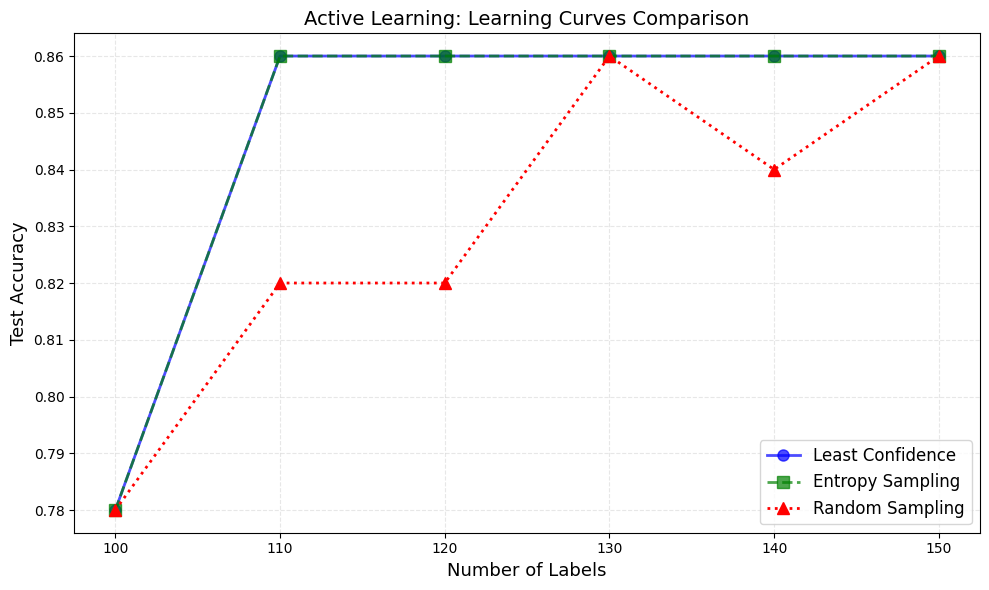


Final Accuracy Comparison
Least Confidence: 0.8600 (with 150 labels)
Entropy Sampling: 0.8600 (with 150 labels)
Random Sampling:  0.8600 (with 150 labels)


In [42]:
# Run active learning with Random Sampling (baseline)
print("=" * 50)
print("=== Random Sampling (Baseline) ===")
print("=" * 50)
np.random.seed(42)
n_labels_random, acc_random = run_active_learning_loop(
    X_seed, y_seed, X_pool, y_pool, X_test, y_test,
    strategy_func=random_sampling, steps=5, batch_size=10
)

# Plot Learning Curves: Number of Labels (X) vs. Accuracy (Y)
plt.figure(figsize=(10, 6))

# Define styling in a more structured way
plt.plot(n_labels_lc, acc_lc, color='blue', marker='o', linestyle='-', label='Least Confidence', linewidth=2, markersize=8, alpha=0.7)
plt.plot(n_labels_entropy, acc_entropy, color='green', marker='s', linestyle='--', label='Entropy Sampling', linewidth=2, markersize=8, alpha=0.7)

# Modified: 'r:^' creates a red (r) dotted (:) line with triangle markers (^)
plt.plot(n_labels_random, acc_random, color='red', marker='^', linestyle=':', label='Random Sampling', linewidth=2, markersize=8)

plt.xlabel('Number of Labels', fontsize=13)
plt.ylabel('Test Accuracy', fontsize=13)
plt.title('Active Learning: Learning Curves Comparison', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save gold standard to file
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print comparison summary
print("\n" + "=" * 50)
print("Final Accuracy Comparison")
print("=" * 50)
print(f"Least Confidence: {acc_lc[-1]:.4f} (with {n_labels_lc[-1]} labels)")
print(f"Entropy Sampling: {acc_entropy[-1]:.4f} (with {n_labels_entropy[-1]} labels)")
print(f"Random Sampling:  {acc_random[-1]:.4f} (with {n_labels_random[-1]} labels)")

In [29]:
import pandas as pd

# Create a dictionary to store the results
# The x-axis (n_labels_lc) serves as our row index
results_data = {
    'Total Labels': n_labels_lc,
    'Least Confidence': [f"{a:.4f}" for a in acc_lc],
    'Entropy Sampling': [f"{a:.4f}" for a in acc_entropy],
    'Random Sampling':  [f"{a:.4f}" for a in acc_random]
}

# Convert to DataFrame
comparison_df = pd.DataFrame(results_data)

# Print the table
print("\n" + "=" * 65)
print("ACCURACY PROGRESSION TABLE (Every 10 Labels)")
print("=" * 65)
print(comparison_df.to_string(index=False))
print("=" * 65)


ACCURACY PROGRESSION TABLE (Every 10 Labels)
 Total Labels Least Confidence Entropy Sampling Random Sampling
          100           0.8400           0.8400          0.8400
          110           0.8600           0.8600          0.8600
          120           0.8600           0.8600          0.8400
          130           0.8600           0.8600          0.8600
          140           0.8600           0.8600          0.8600
          150           0.8600           0.8600          0.8600


## Task 4: AI vs. AI (LLM & Noise Detection) (3 Marks)

**Objective:** Use LLMs for bulk labeling and detect hallucinations.

**Note:**

- Make an account at [open-router](https://openrouter.ai/) and get the API key.
- Use `google/gemini-2.5-flash-lite` (free tier) model as your LLM. Read the documentation on how to use it [here](https://openrouter.ai/google/gemini-2.5-flash-lite/api)
- Set environment variable using .env file and paste your API key in it.

### Part 4.1: LLM Pipeline with Few-Shot Prompting

Design a few-shot prompt with 3 examples from gold standard.
Send remaining unlabeled samples (~150) to Gemini API for labeling.

In [43]:

import os
import time
import json
import requests
import pandas as pd
from dotenv import load_dotenv


load_dotenv()
API_KEY = os.getenv('OPENROUTER_API_KEY')
SITE_URL = "http://localhost:8000"  # for OpenRouter rankings
SITE_NAME = "Student Lab Assignment"

MODEL_NAME = "google/gemini-2.5-flash-lite"

if not API_KEY:
    print("⚠ Warning: OPENROUTER_API_KEY not found. Please create a .env file with:")
    print("  OPENROUTER_API_KEY=your_api_key_here")


def generate_few_shot_prompt(review_text, examples):
    """
    Constructs a few-shot prompt with 3 gold examples + target review.

    Args:
        review_text (str): The review to be labeled
        examples (list): List of 3 example dicts with 'review' and 'label' keys

    Returns:
        str: Formatted prompt string
    """
    prompt = "You are a movie review sentiment classifier. Classify each review as exactly one of: Positive, Negative, or Neutral.\n\n"
    prompt += "Here are some examples:\n\n"

    for i, ex in enumerate(examples, 1):
        prompt += f"Example {i}:\n"
        prompt += f"Review: {ex['review']}\n"
        prompt += f"Sentiment: {ex['label']}\n\n"

    prompt += "Now classify this review. Respond with ONLY one word: Positive, Negative, or Neutral.\n\n"
    prompt += f"Review: {review_text}\nSentiment:"

    return prompt


def query_openrouter(review_text, examples, max_retries=5):
    """
    Sends request to OpenRouter API with retry logic and parsing.

    Args:
        review_text (str): Review to classify
        examples (list): Few-shot examples

    Returns:
        str: Label ('Positive', 'Negative', or 'Neutral')
    """
    url = "https://openrouter.ai/api/v1/chat/completions"

    # Set up headers
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "HTTP-Referer": SITE_URL,
        "X-Title": SITE_NAME,
        "Content-Type": "application/json"
    }

    # Generate prompt
    prompt = generate_few_shot_prompt(review_text, examples)

    # Create payload
    payload = {
        "model": MODEL_NAME,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "max_tokens": 10,
        "temperature": 0.0
    }

    # Implement retry logic
    for attempt in range(max_retries):
        try:
            response = requests.post(url, headers=headers, json=payload, timeout=30)

            if response.status_code == 429:
                wait_time = 2 ** attempt + 5
                print(f"  Rate limited. Waiting {wait_time}s...")
                time.sleep(wait_time)
                continue

            response.raise_for_status()
            result = response.json()

            # Parse response
            content = result['choices'][0]['message']['content'].strip()
            content_lower = content.lower()

            if 'positive' in content_lower:
                return 'Positive'
            elif 'negative' in content_lower:
                return 'Negative'
            elif 'neutral' in content_lower:
                return 'Neutral'
            else:
                print(f"  Unexpected response: '{content}', defaulting to Neutral")
                return 'Neutral'

        except Exception as e:
            print(f"  Attempt {attempt+1} failed: {e}")
            if attempt < max_retries - 1:
                time.sleep(3)
            continue

    print("  All retries failed. Returning Neutral.")
    return 'Neutral'


# --- MAIN EXECUTION ---

# Load gold standard examples for few-shot prompting
gold_df = pd.read_csv('gold_standard_100.csv')

# Select 3 diverse examples (one per sentiment class) for few-shot prompt
examples = []
for label in ['Positive', 'Negative', 'Neutral']:
    sample = gold_df[gold_df['label'] == label].iloc[0]
    examples.append({'review': sample['review'], 'label': label})

print("Few-shot examples selected:")
for ex in examples:
    print(f"  [{ex['label']}] {ex['review'][:80]}...")

# Load remaining unlabeled reviews (~150, select last 150 from movie_reviews_300.csv)
full_df = pd.read_csv('Movie_review - unique_movie_reviews.csv')
llm_reviews = full_df.tail(150).reset_index(drop=True)
print(f"\nReviews to label with LLM: {len(llm_reviews)}")

# Query OpenRouter for each review
llm_labels = []

if API_KEY:
    print("\nQuerying OpenRouter API...")
    for i, row in llm_reviews.iterrows():
        label = query_openrouter(row['review'], examples)
        llm_labels.append(label)
        if (i + 1) % 10 == 0:
            print(f"  Processed {i + 1}/{len(llm_reviews)} reviews...")
        # Respect free tier rate limits (~15 RPM)
        time.sleep(4)
    print(f"\nCompleted LLM labeling: {len(llm_labels)} reviews")


# Save LLM labels to CSV
llm_df = pd.DataFrame({
    'review': llm_reviews['review'].values,
    'label': llm_labels
})

print(f"\nLLM Label Distribution:")
print(llm_df['label'].value_counts())

llm_df.to_csv('llm_labels_150.csv', index=False)
print(f"\nSaved llm_labels_150.csv ({len(llm_df)} reviews)")

Few-shot examples selected:
  [Positive] This movie is a triumph in every sense. Highly recommended for everyone....
  [Negative] I have never been so bored in my life. The score was frankly cringe-worthy. Avoi...
  [Neutral] Middle of the road entertainment. Visually it's fine, but the story arc is just ...

Reviews to label with LLM: 150

Querying OpenRouter API...
  Processed 10/150 reviews...
  Processed 20/150 reviews...
  Processed 30/150 reviews...
  Processed 40/150 reviews...
  Processed 50/150 reviews...
  Processed 60/150 reviews...
  Processed 70/150 reviews...
  Processed 80/150 reviews...
  Processed 90/150 reviews...
  Processed 100/150 reviews...
  Processed 110/150 reviews...
  Processed 120/150 reviews...
  Processed 130/150 reviews...
  Processed 140/150 reviews...
  Processed 150/150 reviews...

Completed LLM labeling: 150 reviews

LLM Label Distribution:
label
Neutral     71
Negative    44
Positive    35
Name: count, dtype: int64

Saved llm_labels_150.csv (150 revi

### Part 4.2: Noise Hunting (Cleanlab Logic)

Train a Logistic Regression model on LLM-labeled data.
Identify "High Confidence Disagreements" where the model is very confident (>0.80) but disagrees with the LLM label.

In [45]:
def find_label_errors(llm_labels, model_probs, review_texts, threshold=0.90):
    """
    Detects high-confidence disagreements between model predictions and LLM labels.
    Implements Cleanlab logic: find cases where model is confident but disagrees with LLM.

    Args:
        llm_labels: List/array of labels from LLM (text or numeric)
        model_probs: Probability matrix from Logistic Regression (shape: N_samples, N_classes)
        review_texts: List of review texts (for display)
        threshold: Confidence threshold (default 0.90)

    Returns:
        list: List of dicts with suspicious review information
    """
    # Get model predictions from probabilities
    preds = np.argmax(model_probs, axis=1)

    # Get model confidence (max probability) for each sample
    confidences = np.max(model_probs, axis=1)

    # Convert llm_labels to numeric if they are strings
    label_to_num = {'Positive': 1, 'Negative': 0, 'Neutral': 2,
                    'positive': 1, 'negative': 0, 'neutral': 2}

    llm_numeric = np.array([
        label_to_num.get(l, 2) if isinstance(l, str) else int(l)
        for l in llm_labels
    ])

    # Find disagreements: model confident (> threshold) but disagrees with LLM
    disagreement_mask = (preds != llm_numeric) & (confidences > threshold)

    # Build list of suspicious reviews
    num_to_label = {0: 'Negative', 1: 'Positive', 2: 'Neutral'}
    suspicious = []

    disagreement_indices = np.where(disagreement_mask)[0]
    for idx in disagreement_indices:
        suspicious.append({
            'index': int(idx),
            'text': review_texts[idx] if idx < len(review_texts) else 'N/A',
            'llm_label': num_to_label.get(int(llm_numeric[idx]), str(llm_numeric[idx])),
            'model_pred': num_to_label.get(int(preds[idx]), str(preds[idx])),
            'confidence': float(confidences[idx])
        })

    # Sort by confidence (highest first) — most egregious errors first
    suspicious.sort(key=lambda x: x['confidence'], reverse=True)

    return suspicious


# Load LLM labels
llm_df = pd.read_csv('llm_labels_150.csv')
print(f"LLM labeled reviews: {len(llm_df)}")

# Vectorize LLM-labeled reviews (use same vectorizer from Task 3)
X_llm = vectorizer.transform(llm_df['review']).toarray()

# Map labels to numeric
label_to_num = {'Positive': 1, 'Negative': 0, 'Neutral': 2}
y_llm = llm_df['label'].map(label_to_num).values

# Train Logistic Regression on LLM-labeled data
model_llm = LogisticRegression(solver='lbfgs', max_iter=1000)
model_llm.fit(X_llm, y_llm)

# Get probabilities on the same data (self-check)
model_probs = model_llm.predict_proba(X_llm)
print(f"Model probability matrix shape: {model_probs.shape}")
print(f"Classes in model: {model_llm.classes_}")

# Find label errors
suspicious_reviews = find_label_errors(
    llm_labels=llm_df['label'].values,
    model_probs=model_probs,
    review_texts=llm_df['review'].values,
    threshold=0.90
)

# Print top 5 suspicious reviews
n_display = min(5, len(suspicious_reviews))
print(f"\n{'='*50}")
print(f"Top {n_display} Suspicious Reviews (High Confidence Disagreements)")
print(f"{'='*50}")

if n_display == 0:
    print("No high-confidence disagreements found with threshold=0.90.")
    print("Trying with lower threshold (0.80)...")
    suspicious_reviews = find_label_errors(
        llm_labels=llm_df['label'].values,
        model_probs=model_probs,
        review_texts=llm_df['review'].values,
        threshold=0.80
    )
    n_display = min(5, len(suspicious_reviews))
    if n_display == 0:
        print("No disagreements found even with threshold=0.80.")
        print("This suggests strong agreement between model and LLM labels.")

for i, review in enumerate(suspicious_reviews[:n_display]):
    print(f"\n--- Suspicious Review #{i+1} ---")
    print(f"  Review:           {review['text'][:100]}...")
    print(f"  LLM Label:        {review['llm_label']}")
    print(f"  Model Prediction:  {review['model_pred']}")
    print(f"  Model Confidence:  {review['confidence']:.4f}")

print(f"\nTotal suspicious reviews found: {len(suspicious_reviews)}")

LLM labeled reviews: 150
Model probability matrix shape: (150, 3)
Classes in model: [0 1 2]

Top 0 Suspicious Reviews (High Confidence Disagreements)
No high-confidence disagreements found with threshold=0.90.
Trying with lower threshold (0.80)...
No disagreements found even with threshold=0.80.
This suggests strong agreement between model and LLM labels.

Total suspicious reviews found: 0


In [30]:
print(model_probs)

[[0.05984749 0.05340264 0.88674987]
 [0.06980047 0.06831927 0.86188025]
 [0.73430474 0.09299825 0.17269701]
 [0.10295345 0.10593728 0.79110927]
 [0.20743056 0.54041879 0.25215065]
 [0.75248087 0.12643611 0.12108301]
 [0.12170602 0.66792261 0.21037137]
 [0.07646739 0.07673743 0.84679518]
 [0.08883899 0.07365391 0.8375071 ]
 [0.14610366 0.10139998 0.75249636]
 [0.15277355 0.57747553 0.26975091]
 [0.08631606 0.08633267 0.82735126]
 [0.1389743  0.69495481 0.1660709 ]
 [0.11523724 0.71371498 0.17104778]
 [0.71975646 0.10471752 0.17552602]
 [0.58335184 0.14481515 0.27183301]
 [0.1176398  0.73734912 0.14501108]
 [0.13627668 0.59325073 0.27047259]
 [0.12004171 0.10279126 0.77716702]
 [0.09709716 0.08276932 0.82013352]
 [0.13693903 0.17164958 0.69141138]
 [0.12193947 0.1184543  0.75960623]
 [0.12761785 0.67502894 0.19735321]
 [0.17949369 0.12530572 0.69520059]
 [0.13788565 0.64982015 0.2122942 ]
 [0.7434421  0.09996972 0.15658819]
 [0.70574982 0.11954361 0.17470657]
 [0.767684   0.09532538 0.13

## Deliverables

**Submission Checklist:**
- [ ] Completed Jupyter Notebook with all tasks (Tasks 1-4)
- [ ] Include your label-studio annotation interface screenshot.
- [ ] gold_standard_100.csv
- [ ] weak_labels_200.csv
- [ ] llm_labels_150.json